# Sickle / non-sickle classifier — supplementary figure regen

Regenerates the per-cell classifier supplementary figure from Goreke et al. (Mol Ther Adv, in press) — the **PR curve + confusion matrix + calibration** triptych.

All metrics are computed on the **out-of-fold (OOF)** predictions: each labeled cell receives exactly one prediction from the fold in which it served as validation. The 5 per-fold prediction dumps live at `sickling/rbc_classification/eval_reports/multimodal_dinov2_frozen_image+morphology_fold{0..4}/report.json` and are loaded by `sickling.rbc_classification.eval.report.read_report`.

The decision threshold is the one that maximises Matthews correlation coefficient (MCC) on the concatenated OOF set. PR-AUC 95 % CIs are non-parametric bootstrap percentiles over 1000 resamples; the PR band is `sickling.rbc_classification.eval.bootstrap.bootstrap_pr_curve`'s output.

**Outputs** (written to `notebooks/figures/`):
- `supplementary_figure_classifier.svg/png` — three-panel composite (paper figure)
- `supplementary_figure_classifier_metrics.csv` — point estimates and CIs

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from sklearn.metrics import (
    average_precision_score,
    confusion_matrix,
    matthews_corrcoef,
)

# Make the sickling package importable when the notebook lives in `notebooks/`
REPO_ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from sickling.rbc_classification.eval.report import read_report
from sickling.rbc_classification.eval.bootstrap import bootstrap_pr_curve

# Editable text in saved SVG/PDF
mpl.rcParams['svg.fonttype'] = 'none'
mpl.rcParams['pdf.fonttype'] = 42

EVAL_REPORTS_DIR = REPO_ROOT / 'sickling' / 'rbc_classification' / 'eval_reports'
MODEL_STEM = 'multimodal_dinov2_frozen_image+morphology'
N_FOLDS = 5
FIGURES_DIR = REPO_ROOT / 'notebooks' / 'figures'
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

print('REPO_ROOT      :', REPO_ROOT)
print('eval reports   :', EVAL_REPORTS_DIR)
print('figures out to :', FIGURES_DIR)

REPO_ROOT      : E:\utku g leica\sickling-publish
eval reports   : E:\utku g leica\sickling-publish\sickling\rbc_classification\eval_reports
figures out to : E:\utku g leica\sickling-publish\notebooks\figures


In [2]:
# Load 5 fold reports + concatenate into a single OOF set.
y_true_parts, y_score_parts = [], []
for fold in range(N_FOLDS):
    report_path = EVAL_REPORTS_DIR / f'{MODEL_STEM}_fold{fold}' / 'report.json'
    if not report_path.exists():
        raise FileNotFoundError(f'fold {fold} report missing: {report_path}')
    rep = read_report(report_path)
    y_true_parts.append(rep.y_true.astype(np.int64))
    y_score_parts.append(rep.y_score.astype(np.float64))
    print(f'  fold {fold}: n={rep.n_val:>4} cells   PR-AUC={rep.metrics.pr_auc:.3f}   MCC={rep.metrics.mcc:.3f}')

y_true_oof = np.concatenate(y_true_parts)
y_score_oof = np.concatenate(y_score_parts)
print()
print(f'OOF total       : {y_true_oof.size} cells')
print(f'positive rate   : {y_true_oof.mean():.3%}')

  fold 0: n= 313 cells   PR-AUC=0.998   MCC=0.967
  fold 1: n= 392 cells   PR-AUC=0.986   MCC=0.939
  fold 2: n= 644 cells   PR-AUC=0.981   MCC=0.920
  fold 3: n= 336 cells   PR-AUC=0.982   MCC=0.933
  fold 4: n= 136 cells   PR-AUC=0.999   MCC=0.769

OOF total       : 1821 cells
positive rate   : 39.154%


In [3]:
# MCC-maximising threshold on the OOF set.
thr_grid = np.linspace(0.01, 0.99, 99)
mccs = np.empty_like(thr_grid)
for i, t in enumerate(thr_grid):
    pred = (y_score_oof >= t).astype(np.int64)
    mccs[i] = matthews_corrcoef(y_true_oof, pred) if np.unique(pred).size == 2 else np.nan
threshold_oof = float(thr_grid[np.nanargmax(mccs)])
mcc_oof = float(np.nanmax(mccs))
y_pred_oof = (y_score_oof >= threshold_oof).astype(np.int64)
cm_oof = confusion_matrix(y_true_oof, y_pred_oof, labels=[0, 1])

# Bootstrap PR-AUC CI + PR band.
pr_auc_pt = float(average_precision_score(y_true_oof, y_score_oof))
rng = np.random.default_rng(42)
boot = []
for _ in range(1000):
    ii = rng.integers(0, y_true_oof.size, size=y_true_oof.size)
    yt = y_true_oof[ii]
    if np.unique(yt).size < 2:
        continue
    boot.append(average_precision_score(yt, y_score_oof[ii]))
pr_auc_lo, pr_auc_hi = (float(x) for x in np.percentile(boot, [2.5, 97.5]))
pr_band = bootstrap_pr_curve(y_true_oof, y_score_oof, n_resamples=1000, seed=42)

print(f'OOF threshold (max MCC) = {threshold_oof:.3f}    MCC = {mcc_oof:.3f}')
print(f'OOF PR-AUC              = {pr_auc_pt:.3f}  [{pr_auc_lo:.3f}, {pr_auc_hi:.3f}]')
print(f'OOF n                   = {y_true_oof.size} cells')
print(f'confusion matrix (rows = true, cols = pred):')
print(cm_oof)

OOF threshold (max MCC) = 0.600    MCC = 0.935
OOF PR-AUC              = 0.988  [0.983, 0.992]
OOF n                   = 1821 cells
confusion matrix (rows = true, cols = pred):
[[1090   18]
 [  38  675]]


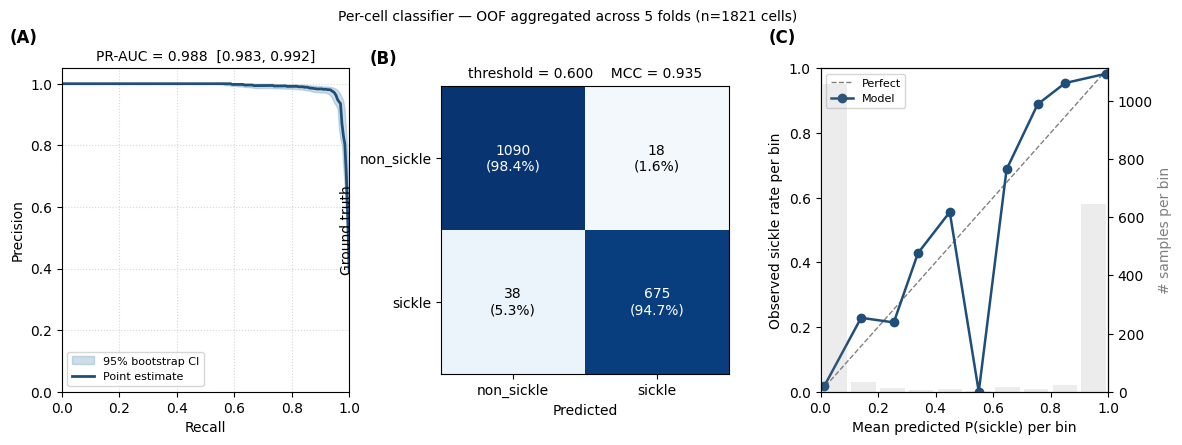

wrote E:\utku g leica\sickling-publish\notebooks\figures\supplementary_figure_classifier.svg
wrote E:\utku g leica\sickling-publish\notebooks\figures\supplementary_figure_classifier.png


In [4]:
# Three-panel supplementary figure: PR curve + confusion matrix + calibration.
cm_norm = cm_oof / cm_oof.sum(axis=1, keepdims=True).clip(min=1)

fig = plt.figure(figsize=(13.5, 4.2))
gs = fig.add_gridspec(1, 3, wspace=0.32)

# --- (A) PR curve with bootstrap 95% band ---
ax_a = fig.add_subplot(gs[0, 0])
ax_a.fill_between(
    pr_band['recall_grid'], pr_band['precision_low'], pr_band['precision_high'],
    alpha=0.25, color='#3a7ca5', label='95% bootstrap CI',
)
ax_a.plot(pr_band['recall_grid'], pr_band['precision_point'],
          color='#1f4e79', linewidth=2.0, label='Point estimate')
ax_a.set_xlabel('Recall'); ax_a.set_ylabel('Precision')
ax_a.set_xlim(0, 1); ax_a.set_ylim(0, 1.05)
ax_a.grid(True, linestyle=':', alpha=0.5)
ax_a.set_title(f'PR-AUC = {pr_auc_pt:.3f}  [{pr_auc_lo:.3f}, {pr_auc_hi:.3f}]', fontsize=10)
ax_a.legend(loc='lower left', fontsize=8)
ax_a.text(-0.18, 1.08, '(A)', transform=ax_a.transAxes, fontweight='bold', fontsize=12)

# --- (B) Confusion matrix at MCC-maximising OOF threshold ---
ax_b = fig.add_subplot(gs[0, 1])
labels = ('non_sickle', 'sickle')
ax_b.imshow(cm_norm, cmap='Blues', vmin=0, vmax=1)
ax_b.set_xticks([0, 1]); ax_b.set_yticks([0, 1])
ax_b.set_xticklabels(labels); ax_b.set_yticklabels(labels)
ax_b.set_xlabel('Predicted'); ax_b.set_ylabel('Ground truth')
for i in range(2):
    for j in range(2):
        ax_b.text(j, i, f'{int(cm_oof[i, j])}\n({cm_norm[i, j]*100:.1f}%)',
                  ha='center', va='center',
                  color='white' if cm_norm[i, j] > 0.5 else 'black')
ax_b.set_title(f'threshold = {threshold_oof:.3f}    MCC = {mcc_oof:.3f}', fontsize=10)
ax_b.text(-0.25, 1.08, '(B)', transform=ax_b.transAxes, fontweight='bold', fontsize=12)

# --- (C) Calibration: mean predicted vs observed sickle rate per bin ---
ax_c = fig.add_subplot(gs[0, 2])
n_bins = 10
bins = np.linspace(0, 1, n_bins + 1)
bin_idx = np.clip(np.digitize(y_score_oof, bins) - 1, 0, n_bins - 1)
mean_pred = np.zeros(n_bins); obs_rate = np.zeros(n_bins); counts = np.zeros(n_bins, dtype=np.int64)
for b in range(n_bins):
    m = bin_idx == b
    counts[b] = int(m.sum())
    if counts[b] > 0:
        mean_pred[b] = float(y_score_oof[m].mean())
        obs_rate[b] = float(y_true_oof[m].mean())
nonempty = counts > 0
ax_c.plot([0, 1], [0, 1], color='gray', linestyle='--', linewidth=1, label='Perfect')
ax_c.plot(mean_pred[nonempty], obs_rate[nonempty], marker='o',
          color='#1f4e79', linewidth=1.8, markersize=6, label='Model')
ax_c2 = ax_c.twinx()
ax_c2.bar(bins[:-1] + (1.0 / n_bins) / 2, counts, width=(1.0 / n_bins) * 0.85,
          alpha=0.15, color='gray')
ax_c2.set_ylabel('# samples per bin', color='gray')
ax_c.set_xlabel('Mean predicted P(sickle) per bin')
ax_c.set_ylabel('Observed sickle rate per bin')
ax_c.set_xlim(0, 1); ax_c.set_ylim(0, 1)
ax_c.legend(loc='upper left', fontsize=8)
ax_c.text(-0.18, 1.08, '(C)', transform=ax_c.transAxes, fontweight='bold', fontsize=12)

fig.suptitle(
    f'Per-cell classifier — OOF aggregated across {N_FOLDS} folds (n={y_true_oof.size} cells)',
    fontsize=10, y=1.02,
)

out_svg = FIGURES_DIR / 'supplementary_figure_classifier.svg'
out_png = FIGURES_DIR / 'supplementary_figure_classifier.png'
fig.savefig(out_svg, bbox_inches='tight')
fig.savefig(out_png, dpi=300, bbox_inches='tight')
plt.show()
print('wrote', out_svg)
print('wrote', out_png)

In [5]:
# Persist the headline numbers as a CSV for the paper Supplementary Table.
rows = [
    {'metric': 'n_cells',          'value': int(y_true_oof.size)},
    {'metric': 'positive_rate',    'value': float(y_true_oof.mean())},
    {'metric': 'threshold_mcc',    'value': threshold_oof},
    {'metric': 'mcc',              'value': mcc_oof},
    {'metric': 'pr_auc',           'value': pr_auc_pt},
    {'metric': 'pr_auc_ci_lo',     'value': pr_auc_lo},
    {'metric': 'pr_auc_ci_hi',     'value': pr_auc_hi},
    {'metric': 'cm_tn',            'value': int(cm_oof[0, 0])},
    {'metric': 'cm_fp',            'value': int(cm_oof[0, 1])},
    {'metric': 'cm_fn',            'value': int(cm_oof[1, 0])},
    {'metric': 'cm_tp',            'value': int(cm_oof[1, 1])},
    {'metric': 'recall_non_sickle','value': float(cm_norm[0, 0])},
    {'metric': 'recall_sickle',    'value': float(cm_norm[1, 1])},
]
metrics_df = pd.DataFrame(rows)
csv_path = FIGURES_DIR / 'supplementary_figure_classifier_metrics.csv'
metrics_df.to_csv(csv_path, index=False)
print('wrote', csv_path)
print()
print(metrics_df.to_string(index=False))

wrote E:\utku g leica\sickling-publish\notebooks\figures\supplementary_figure_classifier_metrics.csv

           metric       value
          n_cells 1821.000000
    positive_rate    0.391543
    threshold_mcc    0.600000
              mcc    0.935385
           pr_auc    0.987986
     pr_auc_ci_lo    0.983064
     pr_auc_ci_hi    0.992239
            cm_tn 1090.000000
            cm_fp   18.000000
            cm_fn   38.000000
            cm_tp  675.000000
recall_non_sickle    0.983755
    recall_sickle    0.946704
